# Trabajo Práctico 1 - Visión por Computadora

### Alumnos:
* BETTIG, Santiago Federico
* DIEGUEZ, Manuel

#### Parte 1

1.a) Implementar el algoritmo White Patchpara librarnos de las diferencias de color de iluminación. \
1.b) Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White patch.

#### Parte 1 - Resolución

Lo primero que vamos a hacer es rrealizar una función para aplicar el algoritmo white-patch. Primero que nada, debemos sabemos en que se basa el algoritmo.

El algoritmo white-patch permite corregir la influencia de la luz sobre el objeto. El algoritmo asume que el valor máximo de cada canal es el color del blanco bajo la luz de la escena, por ende, lo primero que se hace es buscar ese valor máximo:

$$
R_{max}(img): Valor\,máximo\,del\,canal\,R\,de\,la\,imagen \\
G_{max}(img): Valor\,máximo\,del\,canal\,G\,de\,la\,imagen \\
B_{max}(img): Valor\,máximo\,del\,canal\,B\,de\,la\,imagen
$$

Luego debe tomarse ese valor y normalizar cada canal por el coeficiente que representa el valor de la luz blanca

$$
R'(Img) = \frac{255}{R_{max}(Img)}R \\
G'(Img) = \frac{255}{G_{max}(Img)}G \\
B'(Img) = \frac{255}{B_{max}(Img)}B
$$

Pasamos a la definición de la función:

In [2]:
# Importamos las bibliotecas que necesitamos para le resolución
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [ ]:
# Aplica el algoritmo White Patch sobre la imagen que se pasa
# por parámetro
def white_patch(input_image:np.ndarray) -> np.ndarray:
    # Primero que nada, dividimos la imagen en los 3
    # canales
    b, g, r = cv.split(input_image)

    # Obtenemos el valor máximo de cada uno de ellos
    r_max = r.max()
    g_max = g.max()
    b_max = b.max()

    # Normalizamos cada uno de los canales
    r_new = 255/r_max * r
    g_new = 255/g_max * g
    b_new = 255/b_max * b

    # Volvermos a integrar los tres canales, nos aseguramos de que
    # cada canal quede como uint8
    img_white_patch = cv.merge((b_new, g_new, r_new)).astype('uint8')

    return img_white_patch


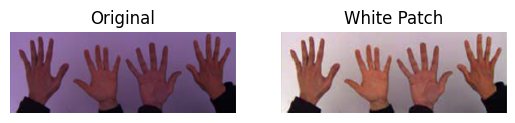

In [82]:
# Definimos cual es la imagen que deseamos leer
img_path = './img/white_patch/test_blue.png'

# Abrimos la imagen con OpenCV
img_i = cv.imread(img_path)

if img_i is not None:
    # Aplicamos la función a la imagen que abrimos:
    img_wp = white_patch(img_i)

    # Mostramos la imagen original
    plt.subplot(121)
    plt.imshow(cv.cvtColor(img_i, cv.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title('Original')

    # Mostramos la imagen luego de aplicado el algoritmo
    plt.subplot(122)
    plt.imshow(cv.cvtColor(img_wp, cv.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title('White Patch')

    plt.show()
else:
    print("No se logró abrir la imagen :(")

#### Conclusiones sobre White Patch



----

#### Parte 2

2.a) Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCV en escala de grises y visualizarlas. \
2.b) Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

#### Parte 2 - Resolución

Lo primero que debemos hacer es abrir las imágenes img1_tp.png y img2_tp.png en escala de grises y visualzarlas.

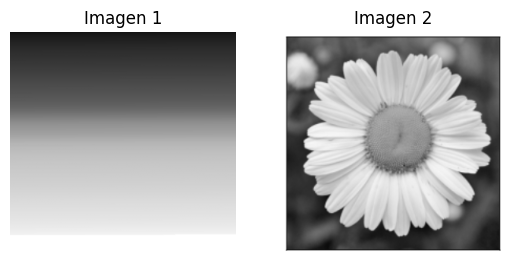

In [114]:
path_img1_tp = './img/img1_tp.png'
path_img2_tp = './img/img2_tp.png'

# Abrimos la imagen 1 en escala de grises
img1_tp = cv.imread(path_img1_tp, cv.IMREAD_GRAYSCALE)
if img1_tp is None:
    print("No se encontró la imagen 1")

# Abrimos la imagen 2 en escala de grises
img2_tp = cv.imread(path_img2_tp, cv.IMREAD_GRAYSCALE)
if img2_tp is None:
    print("No se encontró la imagen 2")

# Mostramos la imagen 1
plt.subplot(121)
plt.imshow(img1_tp, cmap='gray', vmin=0, vmax=255)
plt.axis("off")
plt.title('Imagen 1')

# Mostramos la imagen 2
plt.subplot(122)
plt.imshow(img2_tp, cmap='gray', vmin=0, vmax=255)
plt.axis("off")
plt.title('Imagen 2')

plt.show()

Luego, debemos elegir una cantidad de bins convenientes y graficar sus respectivos histogramas

Text(0.5, 1.0, 'Histograma imagen 2')

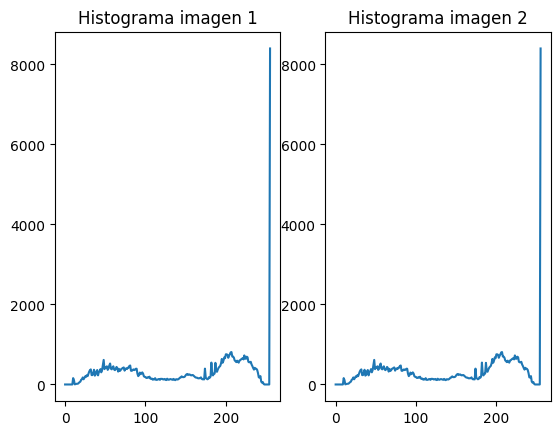

In [115]:
hist1, bins1 = np.histogram(img1_tp.ravel(), 256, [0, 256])
hist2, bins2 = np.histogram(img2_tp.ravel(), 256, [0, 256])

# Mostramos la imagen 1
plt.subplot(121)
plt.plot(hist1)
plt.title('Histograma imagen 1')

# Mostramos la imagen 2
plt.subplot(122)
plt.plot(hist2)
plt.title('Histograma imagen 2')

#### Observaciones

A simple vista vemos un gran problema en los histogramas: existe un pico en torno a los valores mas altos (Cercanos al 255). Esto se debe al predominio del blanco en ambas fotos. Esto podríamos consederarlo como un outlier, por lo que conviene eliminarlo. Una vez eliminado el outlier (solo para la visualización), veremos lo siguiente:


Los histogramas son iguales


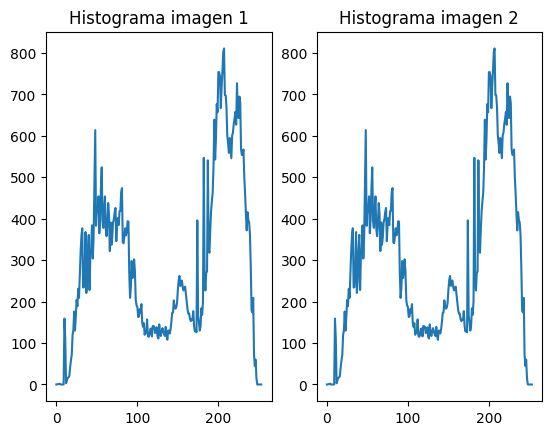

In [120]:
# Mostramos la imagen 1
plt.subplot(121)
plt.plot(hist1[0:254])
plt.title('Histograma imagen 1')

# Mostramos la imagen 2
plt.subplot(122)
plt.plot(hist2[0:254])
plt.title('Histograma imagen 2')

if ((hist1==hist2).all()):
    print("Los histogramas son iguales")
else:
    print("Los histogramas son distintos")


#### Conclusiones

Está mas que claro que el contenido de las fotos distan entre si, por lo que podemos decir que deberían ser claramente diferenciables. El problema es que si vemos el histograma no podremos distinguirlas. En las imágenes anteriores se observa ambos histogramas, correspondientes a las imágenes img1_tp y img2_tp. Comparando ambos histogramas, sabemos que son exactamente iguales, por lo que no será posible distinguir una u otra imagen a partir de los mismos.

En pocas palabras, **no tendrá sentido utilizar el histograma como feature para el entrenamiento de un modelo de detección/clasificación.**